In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import warnings
warnings.filterwarnings('ignore')

from modules import *

plt.rcParams['font.size'] = 14
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['font.family'] = 'Arial'

## Initialization

In [2]:
sys.argv = ['']

# parse args
parser = ArgParser()
args = parser.args

args.reward_std = 2.0
args.jobid = 1

In [3]:
# set experiment path
exp_path = os.path.join(args.path, f'exp_{args.reward_std}_{args.stay_cost}_{args.switch_cost}_{args.jobid}')

In [4]:
# load net
net = torch.load(os.path.join(exp_path, f'net.pth'))

# set environmnet
env = MetaLearningWrapper(
    BanditEnv(
        num_bandits = args.num_bandits,
        value_min = args.value_min,
        value_max = args.value_max,
        value_mean = args.value_mean,
        value_std = args.value_std,
        reward_std = args.reward_std,
        t_max = args.t_max,
        stay_cost = args.stay_cost,
        switch_cost = args.switch_cost,
        scale_factor = args.scale_factor,
    )
)

# load data
data = load_data(os.path.join(exp_path, f'data_simulation.p'))
data = preprocess(data, args, merge_fixations = False)
num_trials = len(data['values'])
print('Keys:', data.keys())
print(num_trials)

Keys: dict_keys(['values', 'action_seqs', 'hidden_seqs', 'lengths', 'fixation_seqs', 'decisions'])
100000


In [5]:
hiddens = [[] for _ in range(5)]
values = []
indices = []
first_fixations = []

for i in range(num_trials):
    length_ep, values_ep, fixation_seq_ep, decision_ep, hidden_seq_ep = pull(
        data, i, 'lengths', 'values', 'fixation_seqs', 'decisions', 'hidden_seqs'
    )

    if length_ep > 1 and length_ep < args.t_max:

        for t in range(5):
            hiddens[t].append(hidden_seq_ep[t])
        first_fixation = fixation_seq_ep[0]
        values.append(np.array([values_ep[first_fixation], values_ep[1 - first_fixation]]))
        indices.append(i)
        first_fixations.append(fixation_seq_ep[0])

for t in range(5):
    hiddens[t] = np.stack(hiddens[t])
values = np.stack(values)
indices = np.array(indices)
first_fixations = np.array(first_fixations)

print(hiddens[0].shape)
print(values.shape)

(99856, 48)
(99856, 2)


In [ ]:
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.linalg import svd

def fit_lasso_decoder(X_train, y_train):
    """
    Fit LASSO model with 10-fold cross-validation to select lambda.
    Returns fitted model.
    """

    # use LassoCV for automatic lambda selection via cross-validation
    # alphas: regularization strengths to try (lambda in the paper)
    alphas = np.logspace(-3, 1, 100)
    
    lasso_cv = LassoCV(
        alphas = alphas,
        cv = 10, # 10-fold cross-validation as specified in paper
        max_iter = 10000,
        random_state = 42,
        n_jobs = -1
    )
    
    lasso_cv.fit(X_train, y_train)
    
    return lasso_cv


def compute_value_weights_for_session(X_train, y1_train, y2_train):
    """
    Compute beta1 and beta2 (LASSO weights) for a single session.
    
    Returns:
        beta1, beta2: weight vectors
    """

    # fit LASSO for 1st value
    lasso1 = fit_lasso_decoder(X_train, y1_train)
    beta1 = lasso1.coef_
    
    # fit LASSO for 2nd value
    lasso2 = fit_lasso_decoder(X_train, y2_train)
    beta2 = lasso2.coef_
    
    return beta1, beta2


def find_value_subspace_basis(beta1, beta2, X):
    """
    Find orthonormal basis for value subspace using Semedo et al. method.
    
    Parameters:
        beta1: weights from LASSO model for 1st value (n_cells,)
        beta2: weights from LASSO model for 2nd value (n_cells,)
        X: spike count matrix (n_trials, n_cells)
    
    Returns:
        Q: orthonormal basis for value subspace (n_cells, 2)
    """
    
    # concatenate weight vectors into n x 2 matrix B
    B = np.column_stack([beta1, beta2]) # (n_cells, 2)
    
    # compute covariance matrix of spike data
    cov_X = np.cov(X.T)
    
    # compute M = B^T × cov(X)
    M = B.T @ cov_X
    
    # SVD of M
    U, D, Vt = svd(M, full_matrices=False)
    V = Vt.T
    
    # take first 2 columns of V (corresponding to non-zero singular values)
    Q = V[:, :2] # (n_cells, 2)
    
    return Q

In [9]:
first_val = values[:, 0]
second_val = values[:, 1]

X = hiddens[4]

train_idx = np.arange(len(indices))[:int(len(indices) / 2)]
test_idx = np.arange(len(indices))[int(len(indices) / 2):]

# make datasets
X_train, X_test = X[train_idx], X[test_idx]
y1_train, y1_test = first_val[train_idx], first_val[test_idx]
y2_train, y2_test = second_val[train_idx], second_val[test_idx]
first_fixations_train, first_fixations_test = first_fixations[train_idx], first_fixations[test_idx]

# compute betas
beta1, beta2 = compute_value_weights_for_session(
    X_train, y1_train, y2_train
)

# find value subspace basis using Semedo method
Q = find_value_subspace_basis(beta1, beta2, X_train)

# project test data into value subspace
X_projected = X_test @ Q  # (n_test_trials, 2)

[0.  0.1] [0.  0.1]
[-0.4304209   0.18491893] [0.  0.1]
[-0.686008    0.14871155] [0.  0.1]
[-0.63347311 -0.19676379] [-0.36884768  0.17203003]
[-0.6273757  -0.25262451] [-0.56105696  0.28248554]


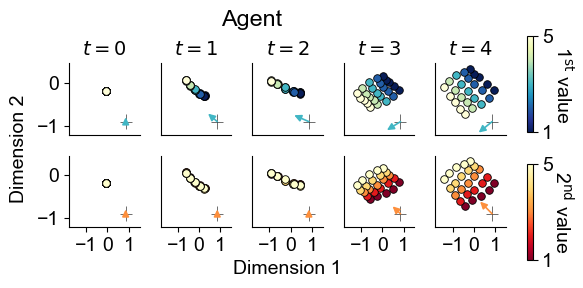

In [ ]:
fig, axes = plt.subplots(2, 5, figsize = (5.5, 3.2))

for t in range(5):
    X = hiddens[t]

    # make datasets
    X_train, X_test = X[train_idx], X[test_idx]
    y1_train, y1_test = first_val[train_idx], first_val[test_idx]
    y2_train, y2_test = second_val[train_idx], second_val[test_idx]

    # project test data into value subspace
    X_projected = X_test @ Q  # (n_test_trials, 2)

    for i in range(2):
        ax = axes[i, t]

        for v1 in [1, 2, 3, 4, 5]:
            for v2 in [1, 2, 3, 4, 5]:
                mask = np.where((y1_test == v1) & (y2_test == v2))[0]
                if np.sum(mask) > 0:
                    mean_pos = X_projected[mask].mean(axis = 0)
                    if i == 0:
                        sc1 = ax.scatter(mean_pos[0], mean_pos[1], s = 30, c = v1, vmin = 1, vmax = 5, cmap = 'YlGnBu_r', marker = 'o', edgecolors = 'k', linewidth = 0.6)
                    else:
                        sc2 = ax.scatter(mean_pos[0], mean_pos[1], s = 30, c = v2, vmin = 1, vmax = 5, cmap = 'YlOrRd_r', marker = 'o', edgecolors = 'k', linewidth = 0.6)

        ax.set_xlim(-1.8, 1.5)
        ax.set_ylim(-1.2, 0.45)


        if t != 0:
            ax.set_yticks([])
        if i == 0:
            ax.set_xticks([])

        if i == 1 and t == 2:
            ax.set_xlabel('Dimension 1')
        # if t == 0:
        #     ax.set_ylabel('Dimension 2')
        if i == 0:
            ax.set_title(rf'$t = {t}$', fontsize = 14)

fig.supylabel('Dimension 2', x = 0.06, y = 0.6, fontsize = 14)
fig.supxlabel('Agent', x = 0.5, y = 0.97, fontsize = 16.8)



colors = ['#41b6c4', '#fd8f3c']

scale_factor = 1
threshold = 0.04
center_x = 0.85
center_y = -0.9
delta_x = 0.28
delta_y = 0.17

for t in range(5):
    X = hiddens[t]

    # make datasets
    X_train, X_test = X[train_idx], X[test_idx]
    y1_train, y1_test = first_val[train_idx], first_val[test_idx]
    y2_train, y2_test = second_val[train_idx], second_val[test_idx]

    # compute betas
    beta1_t, beta2_t = compute_value_weights_for_session(
        X_train, y1_train, y2_train
    )

    # covariance-weighted ("encoding") directions
    # cov across units (H,H)
    cov_X_t = np.cov(X_train.T)

    enc1_t = cov_X_t @ beta1_t   # (H,)
    enc2_t = cov_X_t @ beta2_t   # (H,)

    # project encoding directions into the (fixed) value subspace Q
    enc1_t_proj = enc1_t @ Q * scale_factor   # (2,)
    enc2_t_proj = enc2_t @ Q * scale_factor   # (2,)


    ax = axes[0, t]
    if np.linalg.norm(enc1_t_proj) < threshold:
        enc1_t_proj = np.array([0, 1e-1])
    ax.annotate(
        "",
        xy = (center_x + enc1_t_proj[0], center_y + enc1_t_proj[1]),
        xytext = (center_x, center_y),
        arrowprops = dict(
            arrowstyle = '-|>',
            color = colors[0],
            linewidth = 1.2,
            shrinkA = 0,
            shrinkB = 0,
            mutation_scale = 10
        )
    )
    ax.hlines(y = center_y, xmin = center_x - delta_x, xmax = center_x + delta_x, color = 'k', linewidth = 0.5, alpha = 0.8)
    ax.vlines(x = center_x, ymin = center_y - delta_y, ymax = center_y + delta_y, color = 'k', linewidth = 0.5, alpha = 0.8)

    ax = axes[1, t]
    if np.linalg.norm(enc2_t_proj) < threshold:
        enc2_t_proj = np.array([0, 1e-1])
    ax.annotate(
        "",
        xy = (center_x + enc2_t_proj[0], center_y + enc2_t_proj[1]),
        xytext = (center_x, center_y),
        arrowprops = dict(
            arrowstyle = '-|>',
            color = colors[1],
            linewidth = 1.2,
            shrinkA = 0,
            shrinkB = 0,
            mutation_scale = 10
        )
    )
    ax.hlines(y = center_y, xmin = center_x - delta_x, xmax = center_x + delta_x, color = 'k', linewidth = 0.5, alpha = 0.8)
    ax.vlines(x = center_x, ymin = center_y - delta_y, ymax = center_y + delta_y, color = 'k', linewidth = 0.5, alpha = 0.8)
    print(enc1_t_proj, enc2_t_proj)

cbar_ax1 = fig.add_axes([1, 0.65, 0.01, 0.3])  # [left, bottom, width, height]
cbar_ax2 = fig.add_axes([1, 0.25, 0.01, 0.3])

# # Create the colorbars
cbar1 = fig.colorbar(sc1, cax = cbar_ax1)
cbar2 = fig.colorbar(sc2, cax = cbar_ax2)

cbar1.set_ticks([1, 5])  # Adjust values based on your data range
cbar2.set_ticks([1, 5])  # Example for different range

# # Customize labels (rotation, position, spacing)
cbar1.set_label(r'1$^\text{st}$ value', rotation = 270, labelpad = 15)
cbar2.set_label(r'2$^\text{nd}$ value', rotation = 270, labelpad = 15)

plt.tight_layout()
# plt.show()
plt.savefig('figures/p_time_course.pdf', bbox_inches = 'tight')